In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings .filterwarnings('ignore')

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

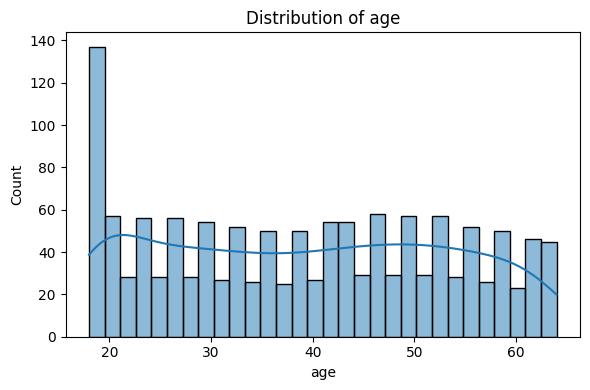

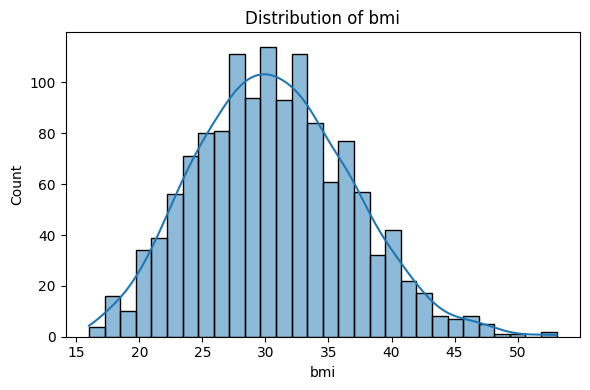

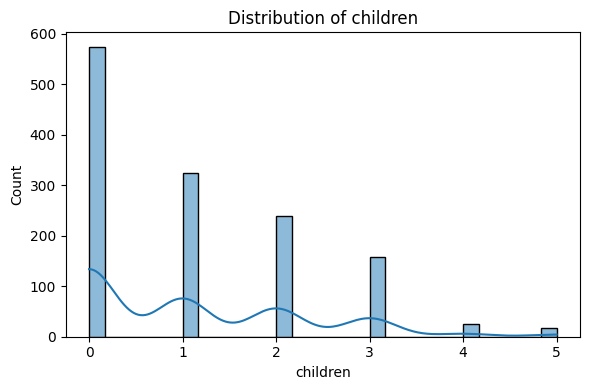

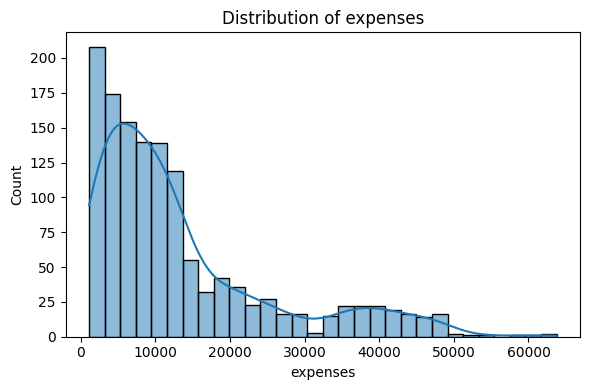

In [8]:
numerical_columns = ["age", "bmi","children","expenses"]
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True, bins = 30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

<Axes: xlabel='children', ylabel='count'>

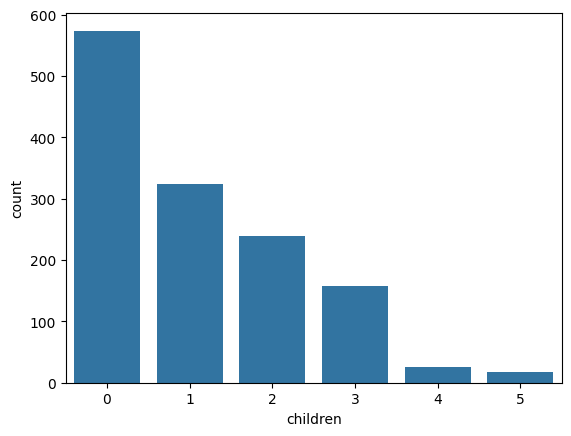

In [9]:
sns.countplot(x = df['children'])


<Axes: xlabel='sex', ylabel='count'>

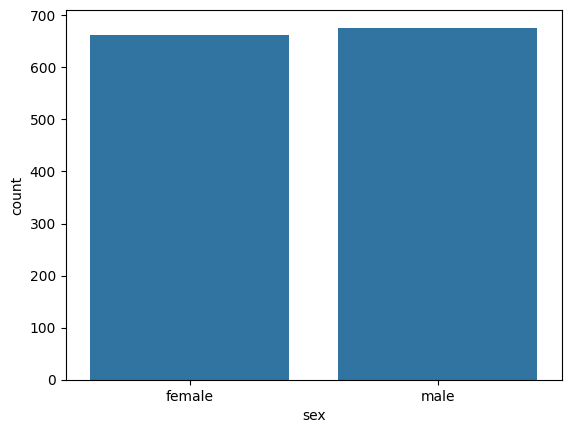

In [10]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

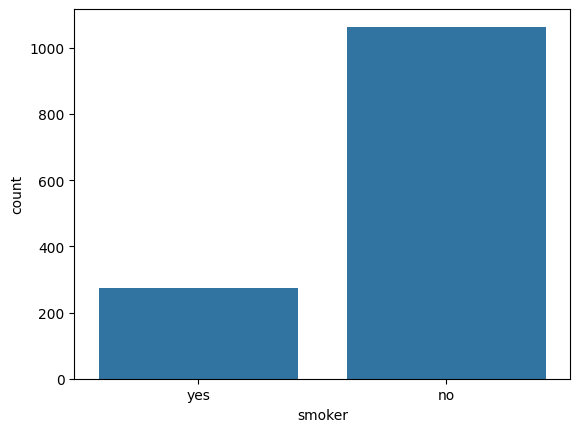

In [11]:
sns.countplot(x=df['smoker'])

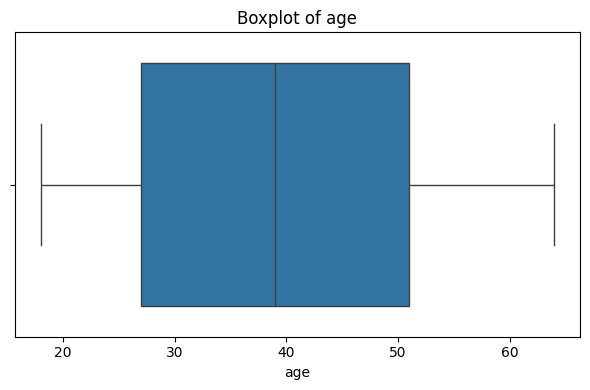

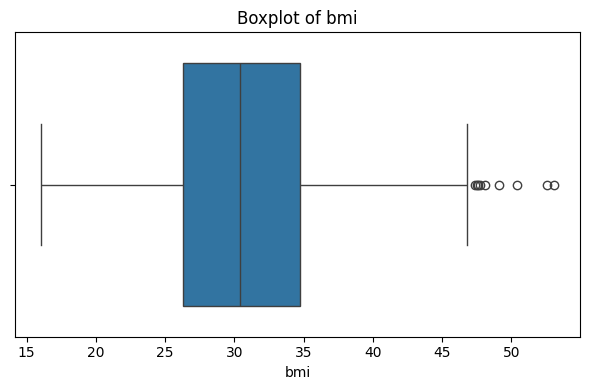

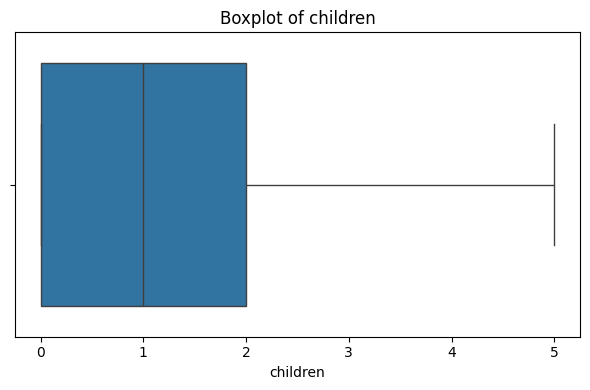

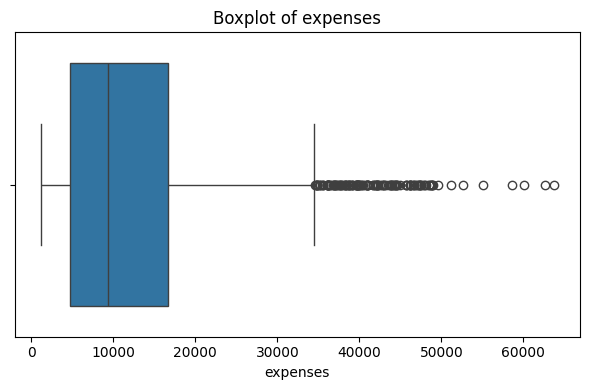

In [12]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

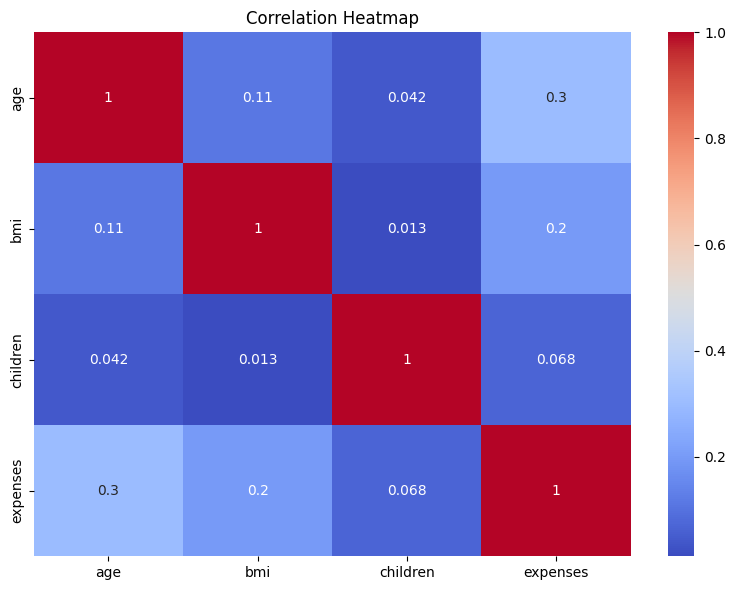

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot = True , cmap= "coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# DATA Cleaning and Preprocessing

In [14]:
df_cleaned= df.copy()

In [15]:
df_cleaned.drop_duplicates( inplace=True)

In [16]:
df_cleaned.shape

(1337, 7)

In [17]:
print("Missing Values:\n",df_cleaned.isnull().sum())

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [18]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

In [19]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [20]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})

In [21]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [22]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0, 'yes': 1})

In [23]:
df_cleaned.head()


,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [24]:
df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

In [25]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)


In [26]:
df_cleaned = df_cleaned.astype(int)

# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

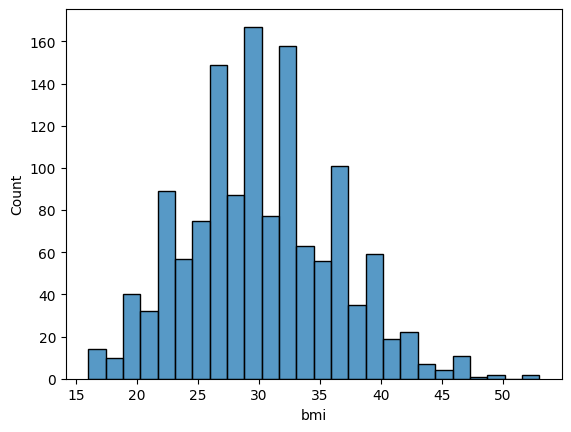

In [27]:
sns.histplot(df_cleaned['bmi'])

In [28]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [29]:
df_cleaned


,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [30]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [31]:
df_cleaned = df_cleaned.astype(int)


In [32]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'expenses',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [33]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])


In [34]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.524321,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.457496,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.457496,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.342502,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.360685,-0.909234,0,3866,1,0,0,0,1,0


In [35]:

from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

# Calculate Pearson correlation
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['expenses'])
    for feature in selected_features
}

# Convert to DataFrame for display
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

# Show the results
correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
4,is_smoker,"(0.7872336877758581, 1.409367603048647e-282)"
0,age,"(0.2983087705662535, 6.97403440077919e-29)"
10,bmi_category_Obese,"(0.20034748362789634, 1.4253538691885453e-13)"
1,bmi,"(0.19771403571907242, 2.991509445616664e-13)"
6,region_southeast,"(0.0735774840796266, 0.0071132820324720705)"
2,children,"(0.06739031003874765, 0.013715680506976774)"
5,region_northwest,"(-0.03869539620435111, 0.15733143199436422)"
7,region_southwest,"(-0.043637082982999204, 0.11074406161799281)"
3,is_female,"(-0.05804599049323582, 0.03381619733251622)"
8,bmi_category_Normal,"(-0.10428293569692478, 0.00013347366215006696)"


In [36]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [37]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [38]:
from scipy.stats import chi2_contingency
import pandas as pd

# Define significance level
alpha = 0.05

# Bin the target variable
df_cleaned['expenses_bin'] = pd.qcut(df_cleaned['expenses'], q=4, labels=False)

# Run Chi-Square test
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['expenses_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Convert to DataFrame
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.873307,0.181313,Accept Null (Drop Feature)
bmi_category_Normal,4.231793,0.237498,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [39]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'expenses',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese',
       'expenses_bin'],
      dtype='object')

In [41]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'expenses','region_southeast','bmi_category_Obese','region_northwest']]

In [42]:
final_df

,age,is_female,bmi,children,is_smoker,expenses,region_southeast,bmi_category_Obese,region_northwest
0,-1.440418,1,-0.524321,-0.909234,1,16884,0,0,0
1,-1.511647,0,0.457496,-0.079442,0,1725,1,1,0
2,-0.799350,0,0.457496,1.580143,0,4449,1,1,0
3,-0.443201,0,-1.342502,-0.909234,0,21984,0,0,1
4,-0.514431,0,-0.360685,-0.909234,0,3866,0,0,1
...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.130224,1.580143,0,10600,0,1,1
1334,-1.511647,1,0.130224,-0.909234,0,2205,0,1,0
1335,-1.511647,1,0.948405,-0.909234,0,1629,1,1,0
1336,-1.297958,1,-0.851594,-0.909234,0,2007,0,0,0


In [43]:
from sklearn.model_selection import train_test_split


In [45]:
X = final_df.drop('expenses', axis=1)
y = final_df['expenses']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [47]:
from sklearn.linear_model import LinearRegression

In [50]:
model = LinearRegression()
LinearRegression()
# model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
model.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)


In [56]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8040002358759406


In [57]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1- r2) * (n-1) / (n - p - 1))
adjusted_r2

0.7979461891076299